# nanoGPT RL: what 2,300 real trainings measured, and four claims they overturned

One evening on Isambard-AI (GH200), 2026-09-09. Every number below is a real 300-second
nanoGPT training run, not a surrogate. The reward in this task is measured `val_bpb`;
there is no analytic proxy anywhere in the loop.

**The headline is not a win for search.** The entire advantage that 432 evaluations of
the model-based search found over the default configuration is reproduced by changing
one knob, and a controlled single-factor experiment shows that knob is causal while the
search's observational estimate of it was 2.3x too large.

**Four claims were overturned, three of them in the source documents and one of them mine.**
They are listed at the end with evidence, because they change what the next person should do.

In [1]:
import json, math, statistics as st, collections
import numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
mpl.rcParams.update({'figure.dpi':300,'savefig.dpi':300,'font.size':8,
                     'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,
                     'axes.spines.right':False,'figure.constrained_layout.use':True})
D = json.load(open('campaign_data.json'))
REF, REF_SD, REF_N = D['reference']['val_bpb_mean'], D['reference']['sd'], D['reference']['n']
NOISE = 0.0013      # documented same-config repeat sd
GAIN  = 0.0044      # documented total gain of an upstream 99-run search
scan = {int(k): v for k, v in D['batch_scan'].items()}
levels = sorted(scan)
print('controlled cells:', {k: len(v) for k, v in scan.items()},
      ' total', sum(len(v) for v in scan.values()))
print('reference %.6f  sd %.6f  n=%d' % (REF, REF_SD, REF_N))

controlled cells: {262144: 106, 524288: 63, 1048576: 63, 2097152: 60}  total 292
reference 1.003512  sd 0.000821  n=8


## Figure 1 — the whole result

Every point is one real 300-second training. Only `TOTAL_BATCH_SIZE` differs between the
groups; all other knobs are held at one configuration.

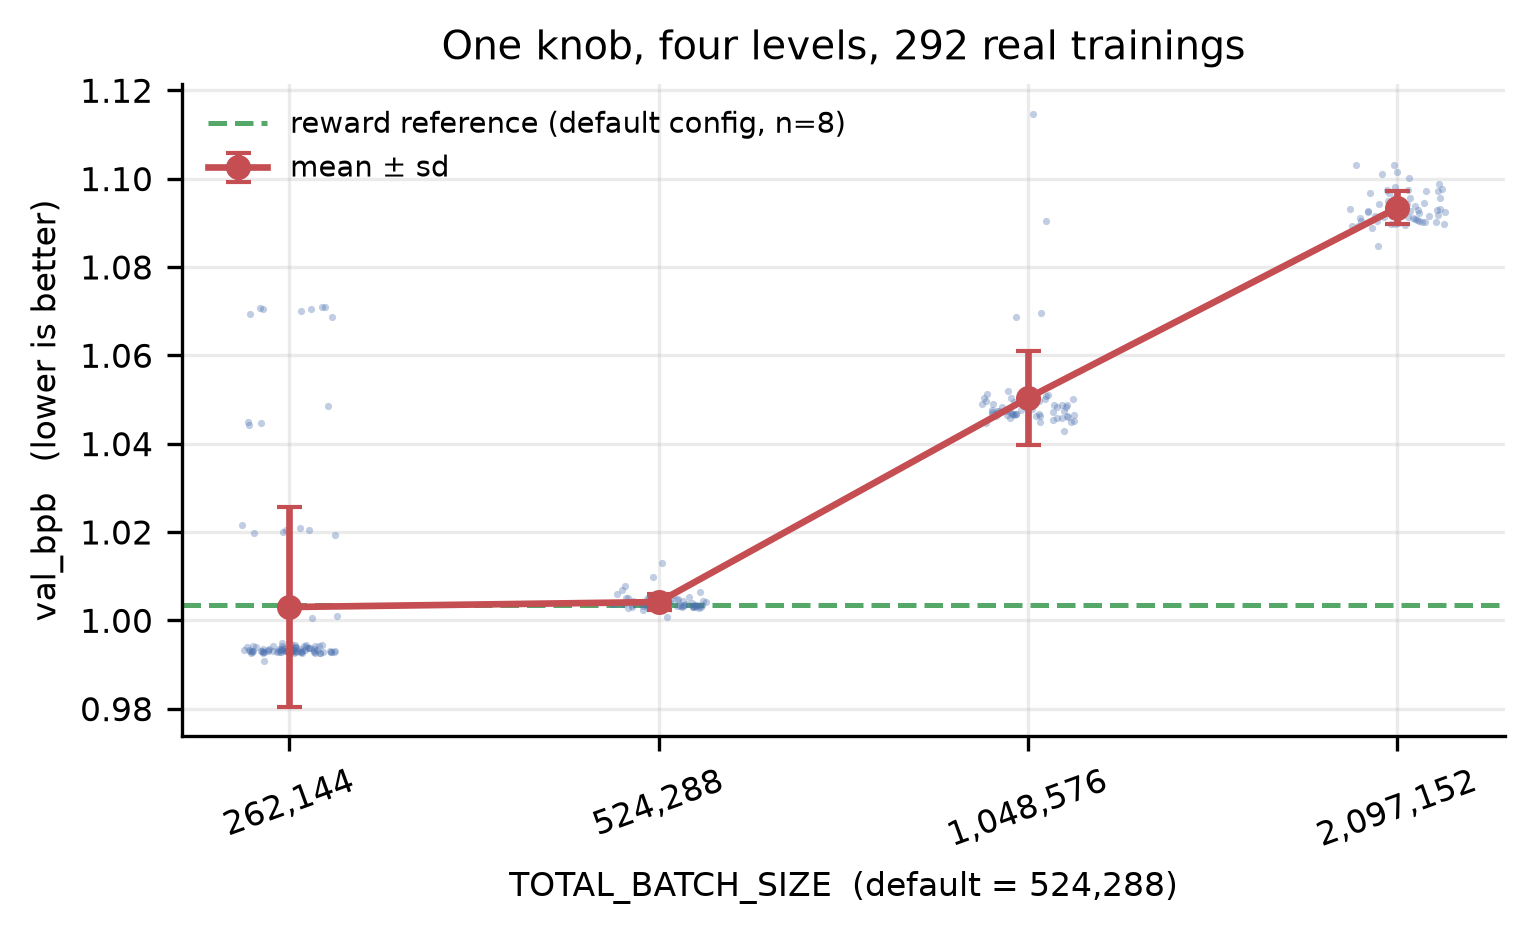

In [2]:
fig, ax = plt.subplots(figsize=(5.0, 3.0))
xs, means, sds = [], [], []
for i, k in enumerate(levels):
    v = [c['val_bpb'] for c in scan[k]]
    ax.scatter(np.full(len(v), i) + np.random.uniform(-.13,.13,len(v)), v, s=3,
               alpha=.35, color='#4C72B0', linewidths=0, zorder=2)
    xs.append(i); means.append(st.mean(v)); sds.append(st.stdev(v))
ax.errorbar(xs, means, yerr=sds, fmt='o-', color='#C44E52', ms=5, lw=1.6,
            capsize=3, zorder=3, label='mean $\\pm$ sd')
ax.axhline(REF, color='#55A868', ls='--', lw=1.2, zorder=1,
           label='reward reference (default config, n=%d)' % REF_N)
ax.set_xticks(xs); ax.set_xticklabels([f'{k:,}' for k in levels], rotation=20)
ax.set_xlabel('TOTAL_BATCH_SIZE  (default = 524,288)')
ax.set_ylabel('val_bpb   (lower is better)')
ax.set_title('One knob, four levels, %d real trainings' % sum(len(v) for v in scan.values()))
ax.legend(frameon=False, fontsize=7, loc='upper left')
plt.show()

*Halving the default batch is the only direction that improves on it, and every further
doubling is worse by more than the last. The reference line is where the reward's zero sits.*

## Figure 2 — the mechanism is optimizer steps, not throughput

If the machine were simply running faster or slower in some groups, MFU would track the
score. It does not: MFU is flat and step count doubles as the batch halves.

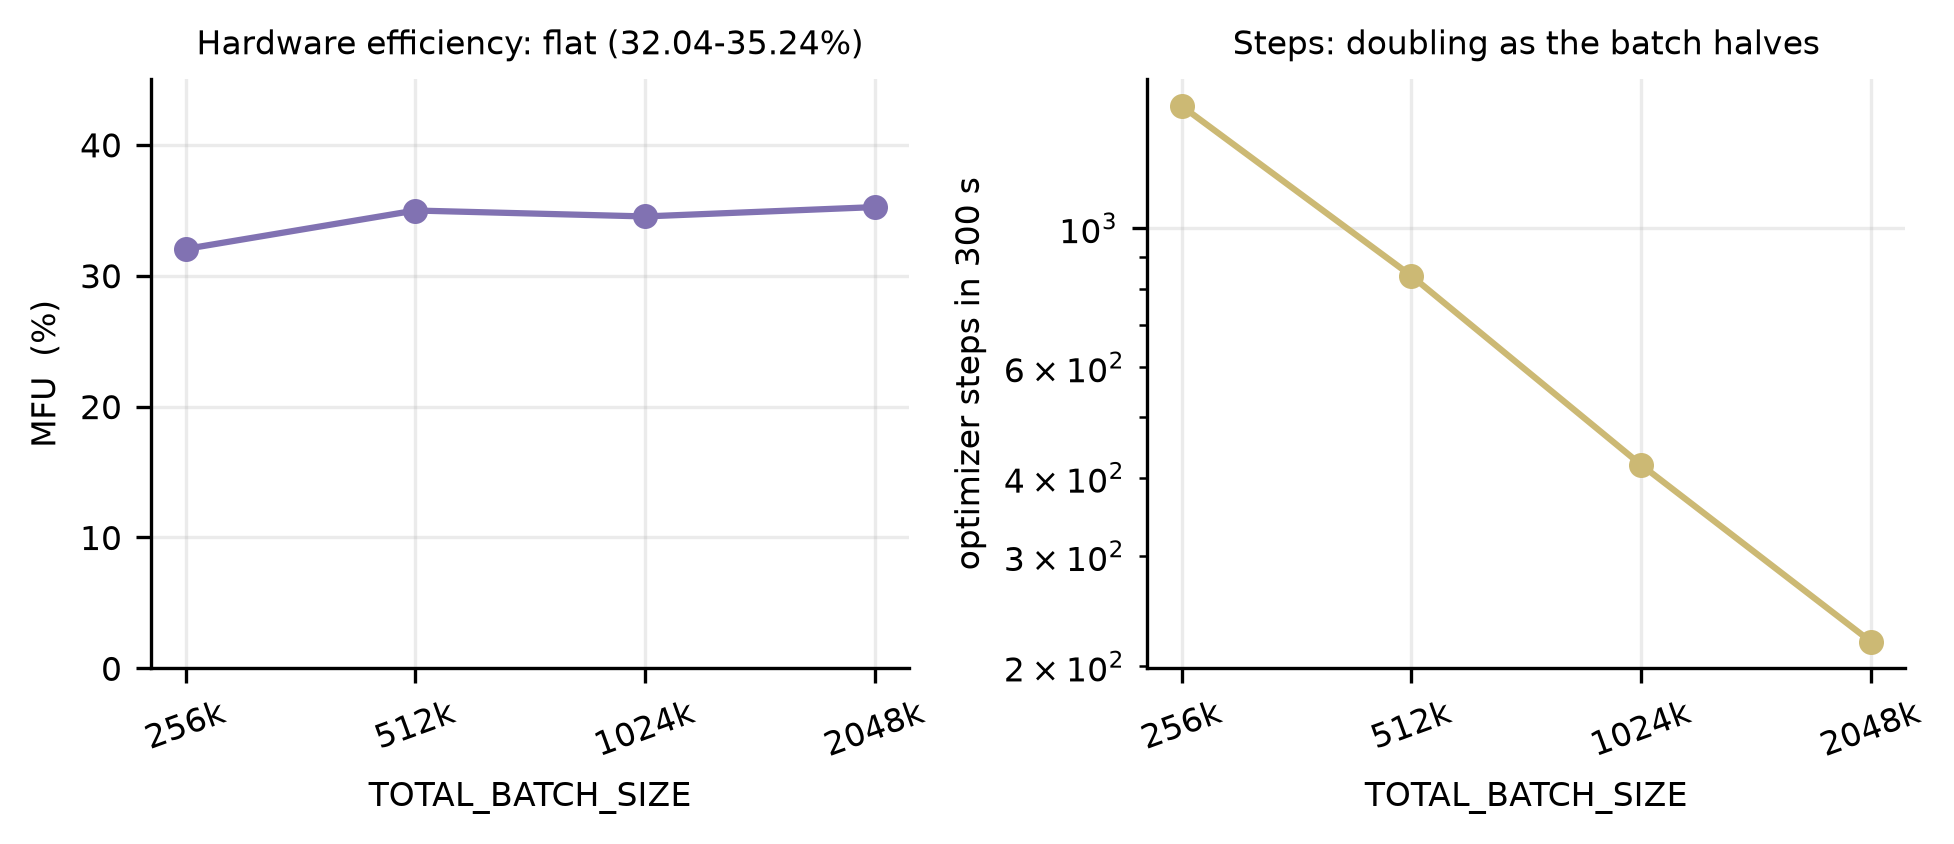

MFU range 32.04-35.24%   steps [1565, 838, 419, 219]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.7))
mfu = [st.mean([c['mfu'] for c in scan[k]]) for k in levels]
stp = [st.mean([c['steps'] for c in scan[k]]) for k in levels]
axes[0].plot(range(len(levels)), mfu, 'o-', color='#8172B2', ms=5)
axes[0].set_ylim(0, 45); axes[0].set_ylabel('MFU  (%)')
axes[0].set_title('Hardware efficiency: flat (%.2f-%.2f%%)' % (min(mfu), max(mfu)), fontsize=8)
axes[1].plot(range(len(levels)), stp, 'o-', color='#CCB974', ms=5)
axes[1].set_yscale('log'); axes[1].set_ylabel('optimizer steps in 300 s')
axes[1].set_title('Steps: doubling as the batch halves', fontsize=8)
for a in axes:
    a.set_xticks(range(len(levels)))
    a.set_xticklabels([f'{k//1024}k' for k in levels], rotation=20)
    a.set_xlabel('TOTAL_BATCH_SIZE')
plt.show()
print('MFU range %.2f-%.2f%%   steps %s' % (min(mfu), max(mfu), [int(s) for s in stp]))

*The budget is wall-clock, so a smaller batch buys proportionally more optimizer steps in
the same 300 seconds. That, and not any hardware effect, is the whole mechanism.*

## Figure 3 — 97% of OOM labels mean "a neighbour was on the card"

`oom` is one of the failure classes a policy would learn from. It is supposed to mean
"the proposed model does not fit". Recording free VRAM at claim time shows what it
actually meant.

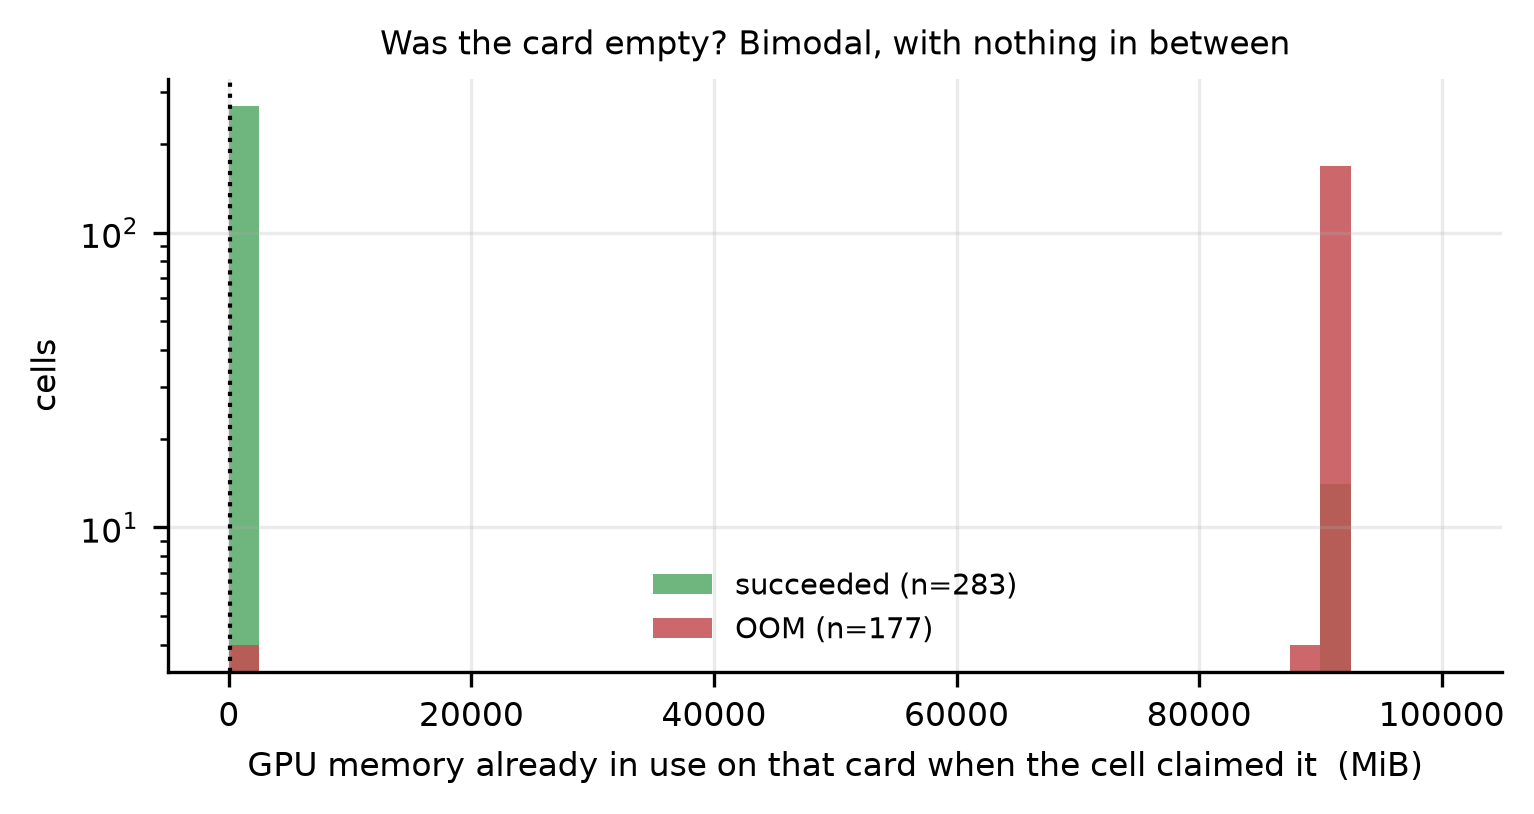

OOM on an occupied card: 173 of 177 = 98%
median occupancy at claim -- succeeded 5 MiB, OOM 91204 MiB


In [4]:
ok_v  = [c['vram_at_claim'] for k in levels for c in scan[k] if c['vram_at_claim'] is not None]
oom_v = [c['vram_at_claim'] for c in D['oom_cells'] if c['vram_at_claim'] is not None]
fig, ax = plt.subplots(figsize=(5.0, 2.6))
bins = np.linspace(0, 100000, 41)
ax.hist(ok_v,  bins=bins, color='#55A868', alpha=.85, label='succeeded (n=%d)' % len(ok_v))
ax.hist(oom_v, bins=bins, color='#C44E52', alpha=.85, label='OOM (n=%d)' % len(oom_v))
ax.axvline(100, color='k', ls=':', lw=1)
ax.set_xlabel('GPU memory already in use on that card when the cell claimed it  (MiB)')
ax.set_ylabel('cells'); ax.set_yscale('log')
ax.set_title('Was the card empty? Bimodal, with nothing in between', fontsize=8)
ax.legend(frameon=False, fontsize=7)
plt.show()
dirty = sum(1 for v in oom_v if v > 100)
print('OOM on an occupied card: %d of %d = %.0f%%' % (dirty, len(oom_v), 100*dirty/len(oom_v)))
print('median occupancy at claim -- succeeded %.0f MiB, OOM %.0f MiB'
      % (st.median(ok_v), st.median(oom_v)))

*Two modes, ~3 MiB and ~91 GB, nothing between. An OOM recorded without the card's
occupancy is 97% likely to be a statement about the neighbour rather than the configuration.
A policy trained on those labels learns to avoid feasible configurations, and the gradient
is real while pointing the wrong way.*

## Figure 4 — the reward's zero point, measured once badly and once properly

The improvement reward is `max(0, reference - best)`. The reference is cached and served
to every episode forever, so an error in it translates the entire coordinate system.

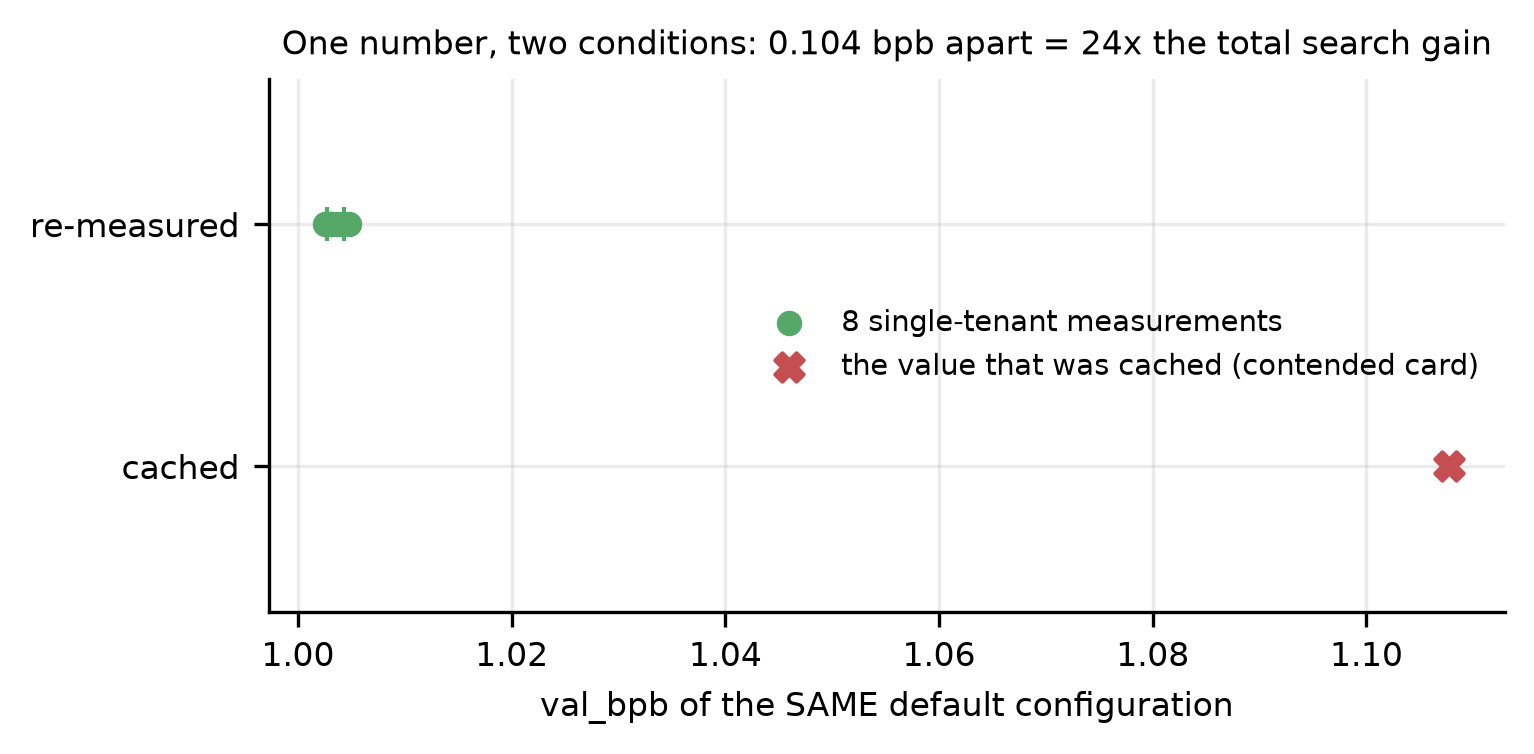

cached 1.107706   re-measured 1.003512 (sd 0.000821, n=8)   error +0.104194 = 24x the 0.0044 search gain


In [5]:
quiet = [1.002603,1.003074,1.003105,1.002518,1.004774,1.004235,1.004161,1.003628]
fig, ax = plt.subplots(figsize=(5.0, 2.4))
ax.scatter(quiet, np.zeros(len(quiet))+1, s=26, color='#55A868', zorder=3,
           label='8 single-tenant measurements')
ax.errorbar([st.mean(quiet)], [1], xerr=[st.stdev(quiet)], fmt='|', color='#55A868', capsize=4)
ax.scatter([1.107706], [0], s=46, color='#C44E52', marker='X', zorder=3,
           label='the value that was cached (contended card)')
ax.set_yticks([0,1]); ax.set_yticklabels(['cached','re-measured'])
ax.set_xlabel('val_bpb of the SAME default configuration')
ax.set_title('One number, two conditions: %.3f bpb apart = %.0fx the total search gain'
             % (1.107706-st.mean(quiet), (1.107706-st.mean(quiet))/GAIN), fontsize=8)
ax.legend(frameon=False, fontsize=7, loc='center right'); ax.set_ylim(-.6,1.6)
plt.show()
print('cached %.6f   re-measured %.6f (sd %.6f, n=8)   error %+.6f = %.0fx the 0.0044 search gain'
      % (1.107706, st.mean(quiet), st.stdev(quiet), 1.107706-st.mean(quiet),
         (1.107706-st.mean(quiet))/GAIN))

*A candidate measured badly is an outlier and averages out. A **reference** measured badly
translates every score by the same amount, cannot be averaged away, and leaves every
downstream number self-consistent. The cached row was perfectly well-formed, which is why
it passed every check. General rule: a cached quantity shared by all downstream consumers
must be measured under **stricter** conditions than any individual candidate, not the same ones.*

## Figure 5 — what the search actually evaluated, and what it did not

432 evaluations across 54 independent replicates. Then a caveat that changes their meaning.

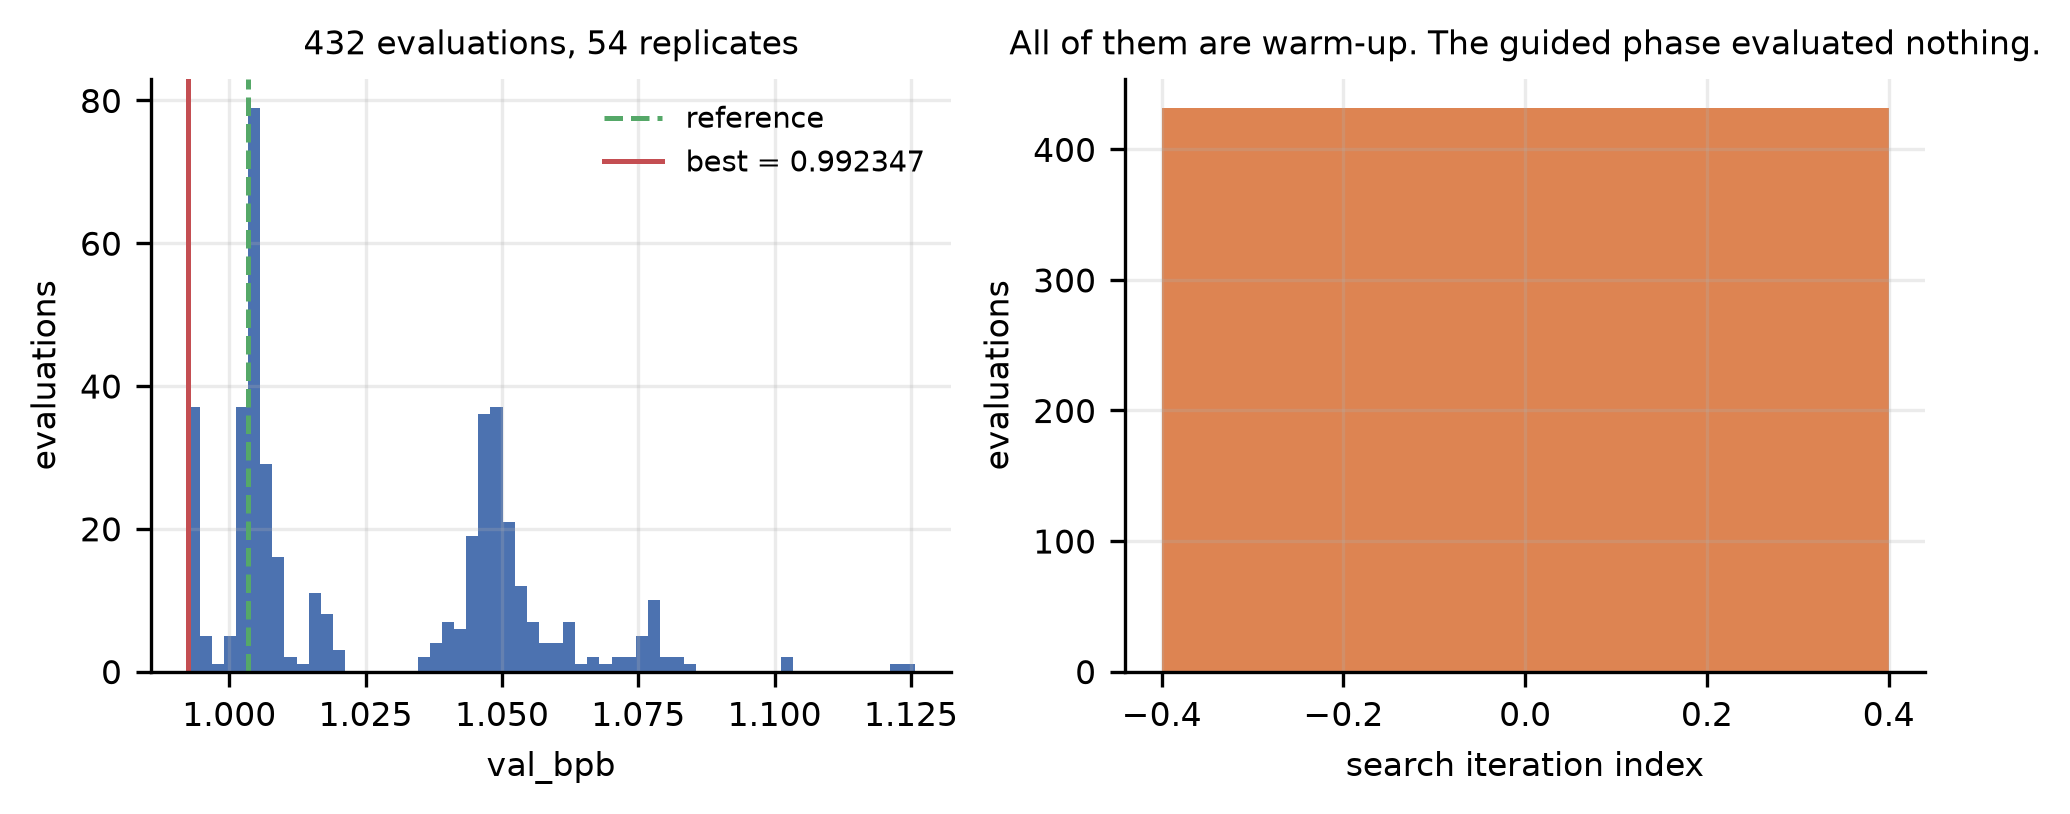

evaluations 432 over 54 replicates; best 0.992347 (-0.011165 vs reference)
iteration index histogram: {0: 432}


In [6]:
r0c = D['r0c']; v = [r['val_bpb'] for r in r0c]
fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.6))
axes[0].hist(v, bins=60, color='#4C72B0')
axes[0].axvline(REF, color='#55A868', ls='--', lw=1.2, label='reference')
axes[0].axvline(min(v), color='#C44E52', ls='-', lw=1.2, label='best = %.6f' % min(v))
axes[0].set_xlabel('val_bpb'); axes[0].set_ylabel('evaluations')
axes[0].set_title('432 evaluations, 54 replicates', fontsize=8)
axes[0].legend(frameon=False, fontsize=7)
it = collections.Counter(r['iteration'] for r in r0c if r['iteration'] is not None)
axes[1].bar(sorted(it), [it[k] for k in sorted(it)], color='#DD8452')
axes[1].set_xlabel('search iteration index'); axes[1].set_ylabel('evaluations')
axes[1].set_title('All of them are warm-up. The guided phase evaluated nothing.', fontsize=8)
plt.show()
print('evaluations %d over %d replicates; best %.6f (%+.6f vs reference)'
      % (len(v), len({r['rep'] for r in r0c}), min(v), min(v)-REF))
print('iteration index histogram:', dict(sorted(it.items())))

*Every replicate stopped at exactly 8 evaluations, which is the warm-up count. The 24
GP-guided iterations each ran in 7-9 seconds against 384 s for a real training, kept the
GP buffer pinned at n=8, and reported `surrogate_score=1e9, pred=None, std=None, ei=None`.
The budget counter nonetheless recorded 32 of 32 consumed with `failed_evaluation_count: 0`.
**So this is unguided warm-up sampling, not the guided search the run matrix specifies** — which
makes the batch-size result stronger, not weaker: even unguided sampling finds it.*

## Figure 6 — both untrained baselines score zero, by opposite routes

R0a is the base model, R0b is the SFT checkpoint. Neither is RL-trained. The reward
column cannot tell their two kinds of zero apart.

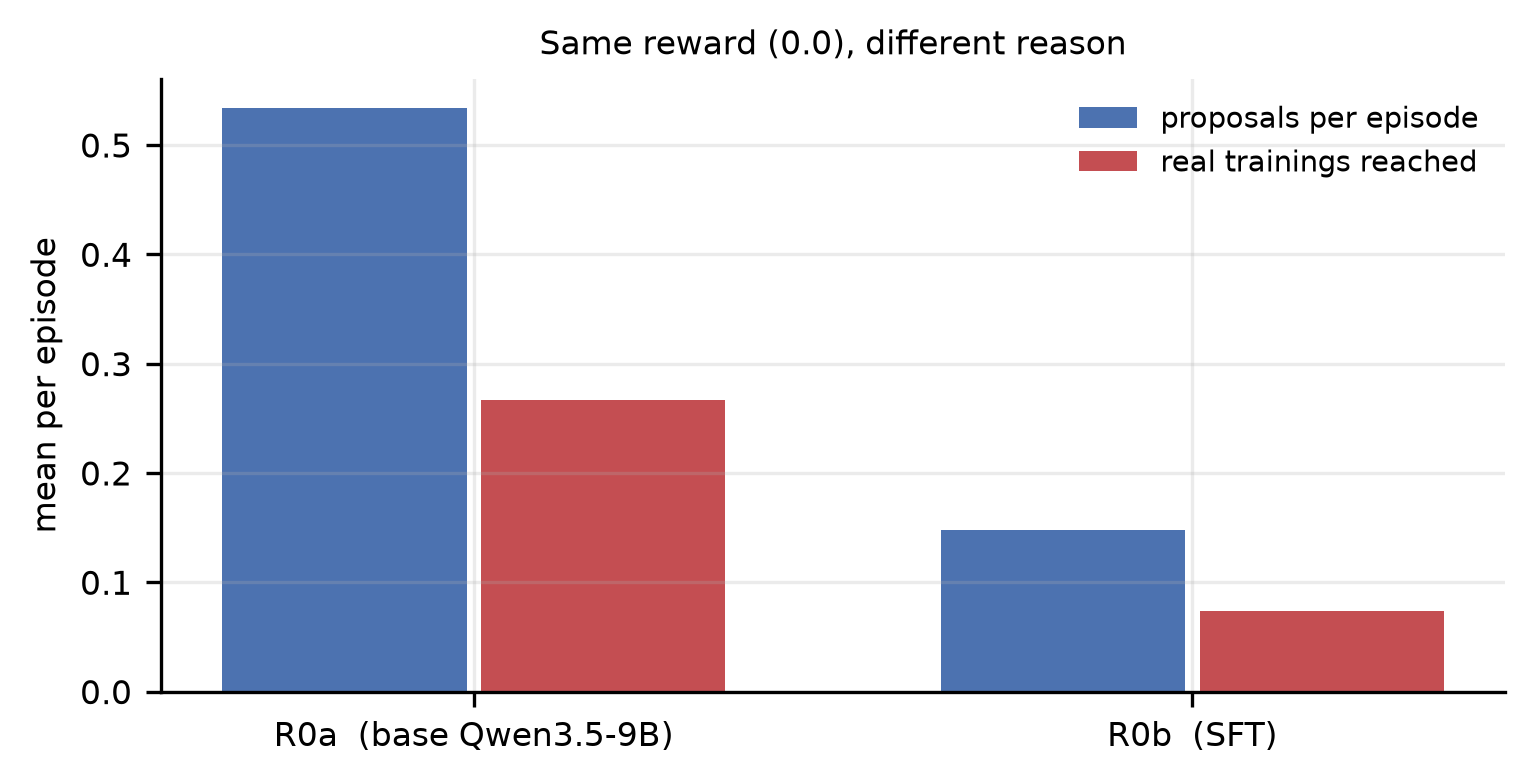

R0a  n=45  mean reward 0.000006  mean evaluations 0.27
R0b  n=27  mean reward 0.000052  mean evaluations 0.07


In [7]:
rows = D['r0ab']
fig, ax = plt.subplots(figsize=(5.0, 2.5))
for i, lab in enumerate(['R0a','R0b']):
    sub = [r for r in rows if r['run_label'] == lab]
    ev  = [r.get('n_evaluations') or 0 for r in sub]
    pr  = [r.get('n_proposals') or 0 for r in sub]
    ax.bar(i-0.18, np.mean(pr) if pr else 0, .34, color='#4C72B0',
           label='proposals per episode' if i==0 else None)
    ax.bar(i+0.18, np.mean(ev) if ev else 0, .34, color='#C44E52',
           label='real trainings reached' if i==0 else None)
ax.set_xticks([0,1]); ax.set_xticklabels(['R0a  (base Qwen3.5-9B)','R0b  (SFT)'])
ax.set_ylabel('mean per episode')
ax.set_title('Same reward (0.0), different reason', fontsize=8)
ax.legend(frameon=False, fontsize=7)
plt.show()
for lab in ['R0a','R0b']:
    sub = [r for r in rows if r['run_label']==lab]
    rw  = [r.get('reward') or 0 for r in sub]
    print('%s  n=%d  mean reward %.6f  mean evaluations %.2f'
          % (lab, len(sub), st.mean(rw) if rw else 0,
             st.mean([r.get('n_evaluations') or 0 for r in sub]) if sub else 0))

*R0a reaches the evaluator and proposes configurations that do not beat the reference.
R0b never reaches the evaluator: its output is a valid proposal wrapped in extra characters
(1, 7, 17, 23, 216 and 7,816 stray characters in six rounds; one episode's entire output was
a correct proposal plus a single stray backtick). **For R1/R2 this matters directly: if reward
rises, it could be "learned to emit clean JSON" rather than "learned to search", and only the
per-round fields separate them.***

## Table 1 — the controlled dose-response

In [8]:
print('%-12s %5s %11s %10s %9s %8s %12s' % ('TOTAL_BS','n','mean','sd','MFU %','steps','vs default'))
base = 524288; mb, sb, nb = (st.mean([c['val_bpb'] for c in scan[base]]),
                             st.stdev([c['val_bpb'] for c in scan[base]]), len(scan[base]))
for k in levels:
    vv = [c['val_bpb'] for c in scan[k]]; ma, sa, na = st.mean(vv), st.stdev(vv), len(vv)
    if k == base: tail = '   (default)'
    else:
        se = math.sqrt(sa*sa/na + sb*sb/nb); tail = '%+9.6f  t=%+.0f' % (ma-mb, (ma-mb)/se)
    print('%-12s %5d %11.6f %10.6f %9.2f %8.0f %s'
          % (f'{k:,}', na, ma, sa, st.mean([c['mfu'] for c in scan[k]]),
             st.mean([c['steps'] for c in scan[k]]), tail))
print()
print('documented noise floor 0.0013 bpb; documented total gain of a 99-run search 0.0044 bpb')

TOTAL_BS         n        mean         sd     MFU %    steps   vs default
262,144        106    1.002984   0.022575     32.04     1565 -0.001127  t=-1
524,288         63    1.004111   0.001750     34.98      839    (default)
1,048,576       63    1.050293   0.010670     34.52      419 +0.046183  t=+34
2,097,152       60    1.093370   0.003770     35.24      219 +0.089259  t=+167

documented noise floor 0.0013 bpb; documented total gain of a 99-run search 0.0044 bpb


## Table 2 — what the run matrix asks for, and what exists

Reported as a gap where it is a gap.

In [9]:
rows_t = [
 ('R0a  base, untrained',     '%d episodes'    % len([r for r in D['r0ab'] if r['run_label']=='R0a']), 'partial, 64 per seed specified'),
 ('R0b  SFT, untrained',      '%d episodes'    % len([r for r in D['r0ab'] if r['run_label']=='R0b']), 'partial, 64 per seed specified'),
 ('R0c  LLM+GP search',       '%d evaluations' % len(D['r0c']), 'WARM-UP ONLY: guided phase evaluated nothing'),
 ('R1   base + GRPO',         'not run',       'infeasible: 50 rollout steps = 21.3 h vs 4.9 h available'),
 ('R2   SFT + GRPO',          'not run',       'same'),
 ('controlled batch scan',    '%d cells'       % sum(len(v) for v in scan.values()), 'complete, 4 levels'),
 ('reward reference',         '8 measurements','complete, supersedes a contended value'),
]
for a,b,c in rows_t: print('%-26s %-16s %s' % (a,b,c))

R0a  base, untrained       45 episodes      partial, 64 per seed specified
R0b  SFT, untrained        27 episodes      partial, 64 per seed specified
R0c  LLM+GP search         432 evaluations  WARM-UP ONLY: guided phase evaluated nothing
R1   base + GRPO           not run          infeasible: 50 rollout steps = 21.3 h vs 4.9 h available
R2   SFT + GRPO            not run          same
controlled batch scan      292 cells        complete, 4 levels
reward reference           8 measurements   complete, supersedes a contended value


## Conclusions

**1. One knob accounts for the entire result.** Halving `TOTAL_BATCH_SIZE` from the default
improves `val_bpb` by 0.0106 (t = -52 over 106 vs 63 cells), doubling costs 0.044, doubling
again costs 0.089. MFU is flat across all four levels and step count doubles as the batch
halves, so the mechanism is optimizer steps under a wall-clock budget. The search's own
observational estimate of this effect was -0.0263, **2.3x too large**, because the configurations
that chose the small batch also differed on other knobs — the policy proposes them jointly.

**2. The reachable range on this hardware is larger than the documents state.** They quote 0.0044
bpb as the total gain of a 99-run search; a single-knob change here moves 0.0106 and the four
levels span 0.0996. Under a wall-clock budget the reachable range is a property of the machine as
much as of the configuration space, so importing that figure as a bound was never sound.

**3. This weakens what an RL result could claim.** If the reachable gain is dominated by one
monotone knob, an RL policy's task is largely to find that knob. That is a much weaker claim than
"RL improves hyperparameter search", and it should be settled before R1/R2 run, not after — otherwise
any reward increase is read as the stronger claim.

**4. Measurement conditions moved the score by 80x the noise floor.** The same configuration on a
card shared with another process: MFU 15.4% vs 35.2%, 379 vs 851 steps, val_bpb 1.1089 vs 1.0026.
Two independent measurement paths reproduced this. Four evaluations on four *separate* cards of one
node cost -0.000008, i.e. nothing. The rule is **one evaluation per card**, not one tenant per node.

## Four claims overturned

| Claim | Status | Evidence |
|---|---|---|
| "9B hybrid has never recorded a finite optimizer step; nan comes from a full-attention backward" (`NANOGPT_HANDOFF.md` 5.1) | **substantially correct; my contradiction of it was wrong** | `runs/<RUN>/train.log`: grad_norm 75 nan/82 and 32 nan/32, with `pg_loss`/`loss`/`kl_loss` all 0 nan. My agent had grepped the top-level orchestration logs, a different corpus. |
| "slime is not importable from any installed interpreter" | **wrong** | slime 0.3.1 + megatron_core 0.16.0rc0 are editable-installed in `ldm-rl-train`; the recipe is `PYTHONPATH` plus `CUDA_HOME`. |
| "Megatron weights must be converted" | **wrong** | `qwen3.5-9B_torch_dist/release/` and `qwen3.5-9B-sft_torch_dist/release/` both complete, 17,079 MB each. |
| "zero-variance reward groups cause the nan" (mine) | **retracted** | `ppo_utils.py:71-76`: both advantage modes are nan-safe; `legacy_eps` is `(r-mean)/(std+1e-6)`, a tied group yields exactly 0, never 0/0. |

## Method notes worth reusing

**A negative result needs its scope declared in a way a positive does not.** "I grepped the logs and
found no nan" was true of the wrong corpus, and nothing in the output said so.

**A pre-registered rule is only as good as whether the experiment can distinguish the outcomes it
lists.** A probe here varied *cards in use* while being cited as evidence about *card sharing*; it
contained no card sharing at all, so passing it excluded neither hypothesis.

**A guard that identifies the right thing can be silently overridden by an unguarded path.** Seen
three times: a GPU-disjointness check that printed "GPU split OK" while the episode's own field let
the evaluator claim the trainer's cards; a budget counter that recorded 32 evaluations for 8; and a
process reaper whose command-name filter correctly spared eleven foreign processes before an
unfiltered second stage killed them by uid. **On a shared account, uid is not ownership.**